In [5]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

# Checking the file PATH
print(os.getcwd())
print(os.path.exists("./tutorial_data/tomo_all_frames.rec"))
print(os.path.exists("./tutorial_project/refined_tomograms/tomo_even_frames+tomo_odd_frames_refined.rec"))

C:\Users\fabio\Coding\Semester_Project_DeepDeWedge\notebooks\tutorial
True
True


In [6]:
from ddw.utils.mrctools import load_mrc_data
#ddw function which loads us correct .rec and .mrc files


# Input / baseline tomogram from filtered back-projection
tomo_input = load_mrc_data("./tutorial_data/tomo_all_frames.rec")

# DeepDeWedge refined tomogram from Step 3
tomo_refined = load_mrc_data(
    "./tutorial_project/refined_tomograms/tomo_even_frames+tomo_odd_frames_refined.rec"
)

print(type(tomo_input), tomo_input.shape)
print(type(tomo_refined), tomo_refined.shape)

<class 'torch.Tensor'> torch.Size([209, 1280, 550])
<class 'torch.Tensor'> torch.Size([209, 1280, 550])


In [7]:
# changing torch vectors into numpy vectors for handling np.fft later on in the notebook
if isinstance(tomo_input, torch.Tensor):
    tomo_input = tomo_input.cpu().numpy()

# changing torch vectors into numpy vectors for handling np.fft later on in the notebook
if isinstance(tomo_refined, torch.Tensor):
    tomo_refined = tomo_refined.cpu().numpy()

print(type(tomo_input), tomo_input.shape)
print(type(tomo_refined), tomo_refined.shape)

<class 'numpy.ndarray'> (209, 1280, 550)
<class 'numpy.ndarray'> (209, 1280, 550)


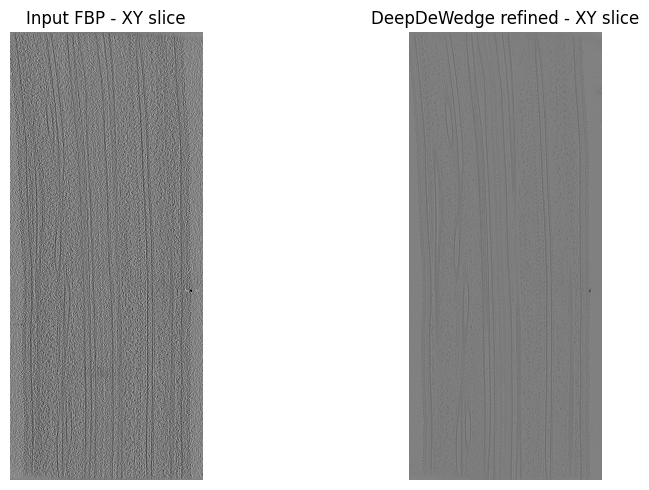

In [8]:
z_mid = tomo_input.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

vmin = -3 * tomo_input.std()
vmax =  3 * tomo_input.std()

axes[0].imshow(tomo_input[z_mid, :, :], cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title("Input FBP - XY slice")
axes[0].axis("off")

axes[1].imshow(tomo_refined[z_mid, :, :], cmap="gray", vmin=vmin, vmax=vmax)
axes[1].set_title("DeepDeWedge refined - XY slice")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Power Spectrum Analysis

In [9]:
def compute_power_spectrum(volume):
    """
    Compute centered 3D power spectrum of a real-space volume.

    Input:
        volume: 3D numpy array, shape usually (z, y, x)

    Output:
        power: 3D numpy array, same shape, centered Fourier power spectrum
    """
    # 3D Fourier transform
    fft_volume = np.fft.fftn(volume)

    # Shift zero frequency to the center for visualization
    fft_volume_shifted = np.fft.fftshift(fft_volume)

    # Power spectrum = squared magnitude of Fourier coefficients
    power = np.abs(fft_volume_shifted) ** 2

    return power


power_input = compute_power_spectrum(tomo_input)
power_refined = compute_power_spectrum(tomo_refined)

print(power_input.shape)
print(power_refined.shape)

(209, 1280, 550)
(209, 1280, 550)


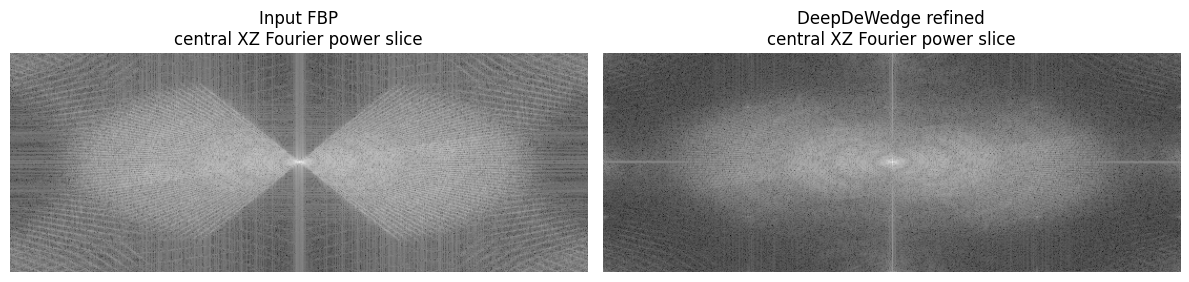

In [13]:
# Central Fourier XZ slice: fix y at the center
y_mid = power_input.shape[1] // 2

power_input_xz = power_input[:, y_mid, :]
power_refined_xz = power_refined[:, y_mid, :]

# Log scale because Fourier power has a huge dynamic range
log_power_input_xz = np.log1p(power_input_xz) #np.log1p(power) is similar to log(1 + power) makes the weak fourier regions visible
log_power_refined_xz = np.log1p(power_refined_xz)


# Use same contrast range for fair comparison
vmin = min(log_power_input_xz.min(), log_power_refined_xz.min())
vmax = max(log_power_input_xz.max(), log_power_refined_xz.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(log_power_input_xz, cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title("Input FBP\ncentral XZ Fourier power slice")
axes[0].axis("off")

axes[1].imshow(log_power_refined_xz, cmap="gray", vmin=vmin, vmax=vmax)
axes[1].set_title("DeepDeWedge refined\ncentral XZ Fourier power slice")
axes[1].axis("off")


os.makedirs("../../figures", exist_ok=True)
save_path = "../../figures/day5_power_spectrum_before_after.png"


plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

In [19]:
#Fourier Shell Correlation
def compute_fsc(vol1, vol2, num_shells=None):
    """
    Compute Fourier Shell Correlation between two 3D volumes.

    Parameters
    ----------
    vol1, vol2 : np.ndarray
        3D volumes with the same shape, usually ordered as (z, y, x).
    num_shells : int or None
        Number of radial Fourier shells. If None, use half the smallest dimension.

    Returns
    -------
    shell_frequencies : np.ndarray
        Normalized shell frequencies from low to high frequency.
    fsc_values : np.ndarray
        FSC values for each shell.
    """
    assert vol1.shape == vol2.shape, "Volumes must have the same shape."

    # Fourier transform and shift zero frequency to center
    F1 = np.fft.fftshift(np.fft.fftn(vol1))
    F2 = np.fft.fftshift(np.fft.fftn(vol2))

    shape = vol1.shape

    if num_shells is None:
        num_shells = min(shape) // 2

    # Create coordinate grid in Fourier space
    z, y, x = np.indices(shape)
    center = np.array(shape) // 2

    # Radial distance from Fourier center
    r = np.sqrt(
        (z - center[0])**2 +
        (y - center[1])**2 +
        (x - center[2])**2
    )

    r_max = min(shape) // 2
    shell_edges = np.linspace(0, r_max, num_shells + 1)

    shell_frequencies = []
    fsc_values = []

    for i in range(num_shells):
        shell_mask = (r >= shell_edges[i]) & (r < shell_edges[i + 1])

        if np.sum(shell_mask) == 0:
            shell_frequencies.append(np.nan)
            fsc_values.append(np.nan)
            continue

        F1_shell = F1[shell_mask]
        F2_shell = F2[shell_mask]

        numerator = np.sum(F1_shell * np.conj(F2_shell))
        denominator = np.sqrt(
            np.sum(np.abs(F1_shell)**2) *
            np.sum(np.abs(F2_shell)**2)
        )

        if denominator == 0:
            fsc = np.nan
        else:
            fsc = np.real(numerator / denominator)

        shell_center = 0.5 * (shell_edges[i] + shell_edges[i + 1])
        normalized_frequency = shell_center / r_max

        shell_frequencies.append(normalized_frequency)
        fsc_values.append(fsc)

    return np.array(shell_frequencies), np.array(fsc_values)

In [20]:
tomo_even = load_mrc_data("./tutorial_data/tomo_even_frames.rec")
tomo_odd = load_mrc_data("./tutorial_data/tomo_odd_frames.rec")

if isinstance(tomo_even, torch.Tensor):
    tomo_even = tomo_even.cpu().numpy()

if isinstance(tomo_odd, torch.Tensor):
    tomo_odd = tomo_odd.cpu().numpy()

print(tomo_even.shape, tomo_odd.shape)

(209, 1280, 550) (209, 1280, 550)


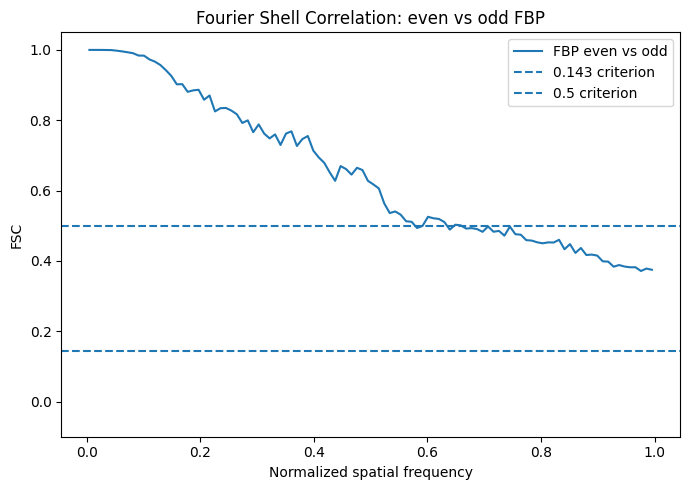

Saved to: C:\Users\fabio\Coding\Semester_Project_DeepDeWedge\figures\day5_fsc_even_odd_fbp.png
File exists: True


In [21]:
freqs, fsc_values = compute_fsc(tomo_even, tomo_odd)

plt.figure(figsize=(7, 5))
plt.plot(freqs, fsc_values, label="FBP even vs odd")
plt.axhline(0.143, linestyle="--", label="0.143 criterion")
plt.axhline(0.5, linestyle="--", label="0.5 criterion")

plt.xlabel("Normalized spatial frequency")
plt.ylabel("FSC")
plt.title("Fourier Shell Correlation: even vs odd FBP")
plt.ylim(-0.1, 1.05)
plt.legend()
plt.tight_layout()

os.makedirs("../../figures", exist_ok=True)
save_path = "../../figures/day5_fsc_even_odd_fbp.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", os.path.abspath(save_path))
print("File exists:", os.path.exists(save_path))